# Nível Intermediário: Categorical Naïve Bayes

Classificação de perfil de risco a partir de atributos categóricos.

Etapas adicionadas: **matriz de confusão (gráfico)**, **curva ROC**, **gravação do modelo (pipeline) em arquivo (.pkl)** e um **app Streamlit** de exemplo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

In [2]:
# 1. Geração de massa de dados categóricos estruturados (Pandas Dataframe)
np.random.seed(42)
n_samples = 1000

dados = pd.DataFrame({
    'escolaridade': np.random.choice(['Medio', 'Superior', 'Pos-Graduacao'], size=n_samples, p=[0.4, 0.4, 0.2]),
    'renda_faixa': np.random.choice(['Baixa', 'Media', 'Alta'], size=n_samples, p=[0.3, 0.5, 0.2]),
    'historico_credito': np.random.choice(['Ruim', 'Bom', 'Excelente'], size=n_samples, p=[0.2, 0.6, 0.2]),
    'perfil_risco': np.random.choice(['Baixo', 'Alto'], size=n_samples, p=[0.7, 0.3]) # Target
})

# Separação de features (X) e rótulo (y)
X = dados[['escolaridade', 'renda_faixa', 'historico_credito']]
y = dados['perfil_risco']

categorical_cols = X.columns.tolist()

In [3]:
# 2. Pré-processamento e construção da Pipeline
# O CategoricalNB exige dados codificados numericamente para categorias
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

In [4]:
# 3. Validação Cruzada (5-folds) para verificar estabilidade do modelo
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

In [5]:
# 4. Divisão Treino/Teste e Ajuste Final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['escolaridade',
                                                   'renda_faixa',
                                                   'historico_credito'])])),
                ('classifier', CategoricalNB())])

In [6]:
# 5. Avaliação do Modelo
y_pred = pipeline.predict(X_test)

print("=== Nível Intermediário: Categorical Naïve Bayes ===")
print(f"Média Acurácia (Cross-Validation 5-Fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")
print("Matriz de Confusão:")
labels_order = pipeline.classes_.tolist()
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

=== Nível Intermediário: Categorical Naïve Bayes ===
Média Acurácia (Cross-Validation 5-Fold): 0.7190 (+/- 0.0020)

Matriz de Confusão:
[[  0  70]
 [  0 180]]

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00        70
       Baixo       0.72      1.00      0.84       180

    accuracy                           0.72       250
   macro avg       0.36      0.50      0.42       250
weighted avg       0.52      0.72      0.60       250



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Matriz de Confusão (gráfico)

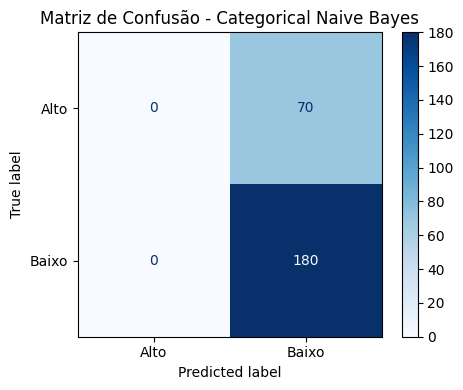

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusão - Categorical Naive Bayes")
plt.tight_layout()
plt.show()

## Curva ROC

Como o alvo é categórico ('Baixo'/'Alto'), definimos a classe positiva explicitamente.

AUC (classe positiva='Alto'): 0.4530


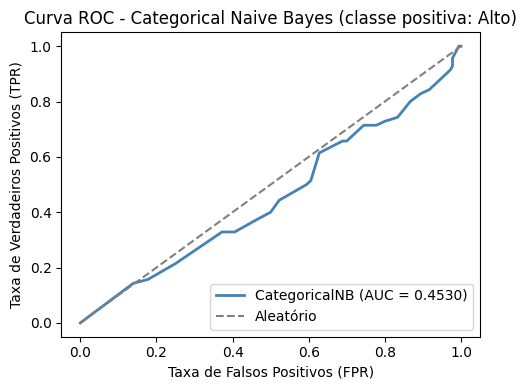

In [8]:
pos_label = "Alto"
pos_idx = labels_order.index(pos_label)
y_proba = pipeline.predict_proba(X_test)[:, pos_idx]

fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=pos_label)
auc = roc_auc_score((y_test == pos_label).astype(int), y_proba)
print(f"AUC (classe positiva='{pos_label}'): {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"CategoricalNB (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.set_title(f"Curva ROC - Categorical Naive Bayes (classe positiva: {pos_label})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

> **Nota:** este dataset é sintético e as colunas de entrada foram geradas de forma
> independente do alvo `perfil_risco`. Por isso é esperado que a acurácia e a AUC
> fiquem próximas do acaso — o pipeline (pré-processamento + modelo + serialização)
> é o ponto didático deste exemplo, não o poder preditivo em si.

## Gravar o modelo (pipeline completo em arquivo .pkl)

In [9]:
with open("modelo_02_categoricalnb.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Modelo salvo em modelo_02_categoricalnb.pkl")

Modelo salvo em modelo_02_categoricalnb.pkl
